# YOLO26n Warm-Start On Top-Down People v1i

Use this notebook to prepare and train a **bottom-camera warm-start model** on the local Roboflow dataset:

`Zipped files/top down people.v1i.yolov8`

This notebook assumes the **bottom camera task is top-down person detection**.

Important:
- The source dataset has **4 overlapping classes** (`pedestrian`, `human`, `human-pedestrian-people`, `person`).
- This notebook **merges them into 1 class** called `person`.
- This is a **warm-start dataset**, not your final proof dataset.
- Only use this warm-start if your future custom bottom-camera labels are also **person boxes**. If you later decide to label **heads**, stop using this path and switch to a head-labeled dataset for warm-start.

In [1]:
from __future__ import annotations

import random
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Markdown, display
from PIL import Image, ImageDraw
from ultralytics import YOLO


In [2]:
ROOT = Path.cwd()
if not (ROOT / 'train').exists():
    ROOT = ROOT.parent

SOURCE_ROOT = ROOT / 'Zipped files' / 'top down people.v1i.yolov8'
SOURCE_YAML = SOURCE_ROOT / 'data.yaml'
PROCESSED_ROOT = ROOT / 'datasets' / 'processed' / 'top_down_people_v1i_person_yolo26'
PROCESSED_YAML = PROCESSED_ROOT / 'data.yaml'
RUNS_DIR = ROOT / 'train' / 'runs'

YOLO26_LOCAL = ROOT / 'notebooks' / 'yolo26n.pt'
MODEL_SOURCE = str(YOLO26_LOCAL if YOLO26_LOCAL.exists() else 'yolo26n.pt')

display(Markdown(f'**Workspace Root:** `{ROOT}`'))
display(Markdown(f'**Source Dataset:** `{SOURCE_ROOT}`'))
display(Markdown(f'**Processed Dataset Output:** `{PROCESSED_ROOT}`'))
display(Markdown(f'**YOLO26 Source:** `{MODEL_SOURCE}`'))


**Workspace Root:** `c:\Users\PC\Desktop\Term252\Senior Project II`

**Source Dataset:** `c:\Users\PC\Desktop\Term252\Senior Project II\Zipped files\top down people.v1i.yolov8`

**Processed Dataset Output:** `c:\Users\PC\Desktop\Term252\Senior Project II\datasets\processed\top_down_people_v1i_person_yolo26`

**YOLO26 Source:** `c:\Users\PC\Desktop\Term252\Senior Project II\notebooks\yolo26n.pt`

In [3]:
dataset_yaml = yaml.safe_load(SOURCE_YAML.read_text(encoding='utf-8'))

split_rows = []
for split_name, folder_name in [('train', 'train'), ('val', 'valid'), ('test', 'test')]:
    image_dir = SOURCE_ROOT / folder_name / 'images'
    label_dir = SOURCE_ROOT / folder_name / 'labels'
    split_rows.append({
        'split': split_name,
        'images': len(list(image_dir.glob('*.*'))),
        'labels': len(list(label_dir.glob('*.txt'))),
    })

display(pd.DataFrame(split_rows))
display(Markdown(f"**Original classes:** `{dataset_yaml['names']}`"))


,split,images,labels
0,train,975,975
1,val,63,63
2,test,14,14


**Original classes:** `['0 pedestrian', 'human', 'human-pedestrian-people', 'person']`

In [4]:
def remap_dataset_to_single_person_class(source_root: Path, processed_root: Path) -> dict[str, int]:
    processed_root.mkdir(parents=True, exist_ok=True)
    box_counter = Counter()

    split_map = {'train': 'train', 'val': 'valid', 'test': 'test'}
    for target_split, source_split in split_map.items():
        src_img_dir = source_root / source_split / 'images'
        src_lbl_dir = source_root / source_split / 'labels'
        dst_img_dir = processed_root / target_split / 'images'
        dst_lbl_dir = processed_root / target_split / 'labels'
        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_lbl_dir.mkdir(parents=True, exist_ok=True)

        for image_path in sorted(src_img_dir.glob('*.*')):
            shutil.copy2(image_path, dst_img_dir / image_path.name)

        for label_path in sorted(src_lbl_dir.glob('*.txt')):
            out_lines = []
            for line in label_path.read_text(encoding='utf-8').splitlines():
                if not line.strip():
                    continue
                parts = line.split()
                if len(parts) != 5:
                    continue
                _old_class, xc, yc, w, h = parts
                out_lines.append(f'0 {xc} {yc} {w} {h}')
                box_counter[target_split] += 1
            (dst_lbl_dir / label_path.name).write_text('\n'.join(out_lines) + ('\n' if out_lines else ''), encoding='utf-8')

    yaml_text = '\n'.join([
        f'path: {processed_root.as_posix()}',
        'train: train/images',
        'val: val/images',
        'test: test/images',
        '',
        'nc: 1',
        "names: ['person']",
        '',
        'source_dataset: top down people.v1i.yolov8',
        'label_merge: merged original 4 classes into one person class',
    ])
    (processed_root / 'data.yaml').write_text(yaml_text + '\n', encoding='utf-8')
    return dict(box_counter)


merged_box_counts = remap_dataset_to_single_person_class(SOURCE_ROOT, PROCESSED_ROOT)
display(pd.DataFrame([
    {'split': split, 'merged_boxes': count}
    for split, count in merged_box_counts.items()
]).sort_values('split'))
display(Markdown(f'**Processed YAML:** `{PROCESSED_YAML}`'))


,split,merged_boxes
2,test,157
0,train,9913
1,val,582


**Processed YAML:** `c:\Users\PC\Desktop\Term252\Senior Project II\datasets\processed\top_down_people_v1i_person_yolo26\data.yaml`

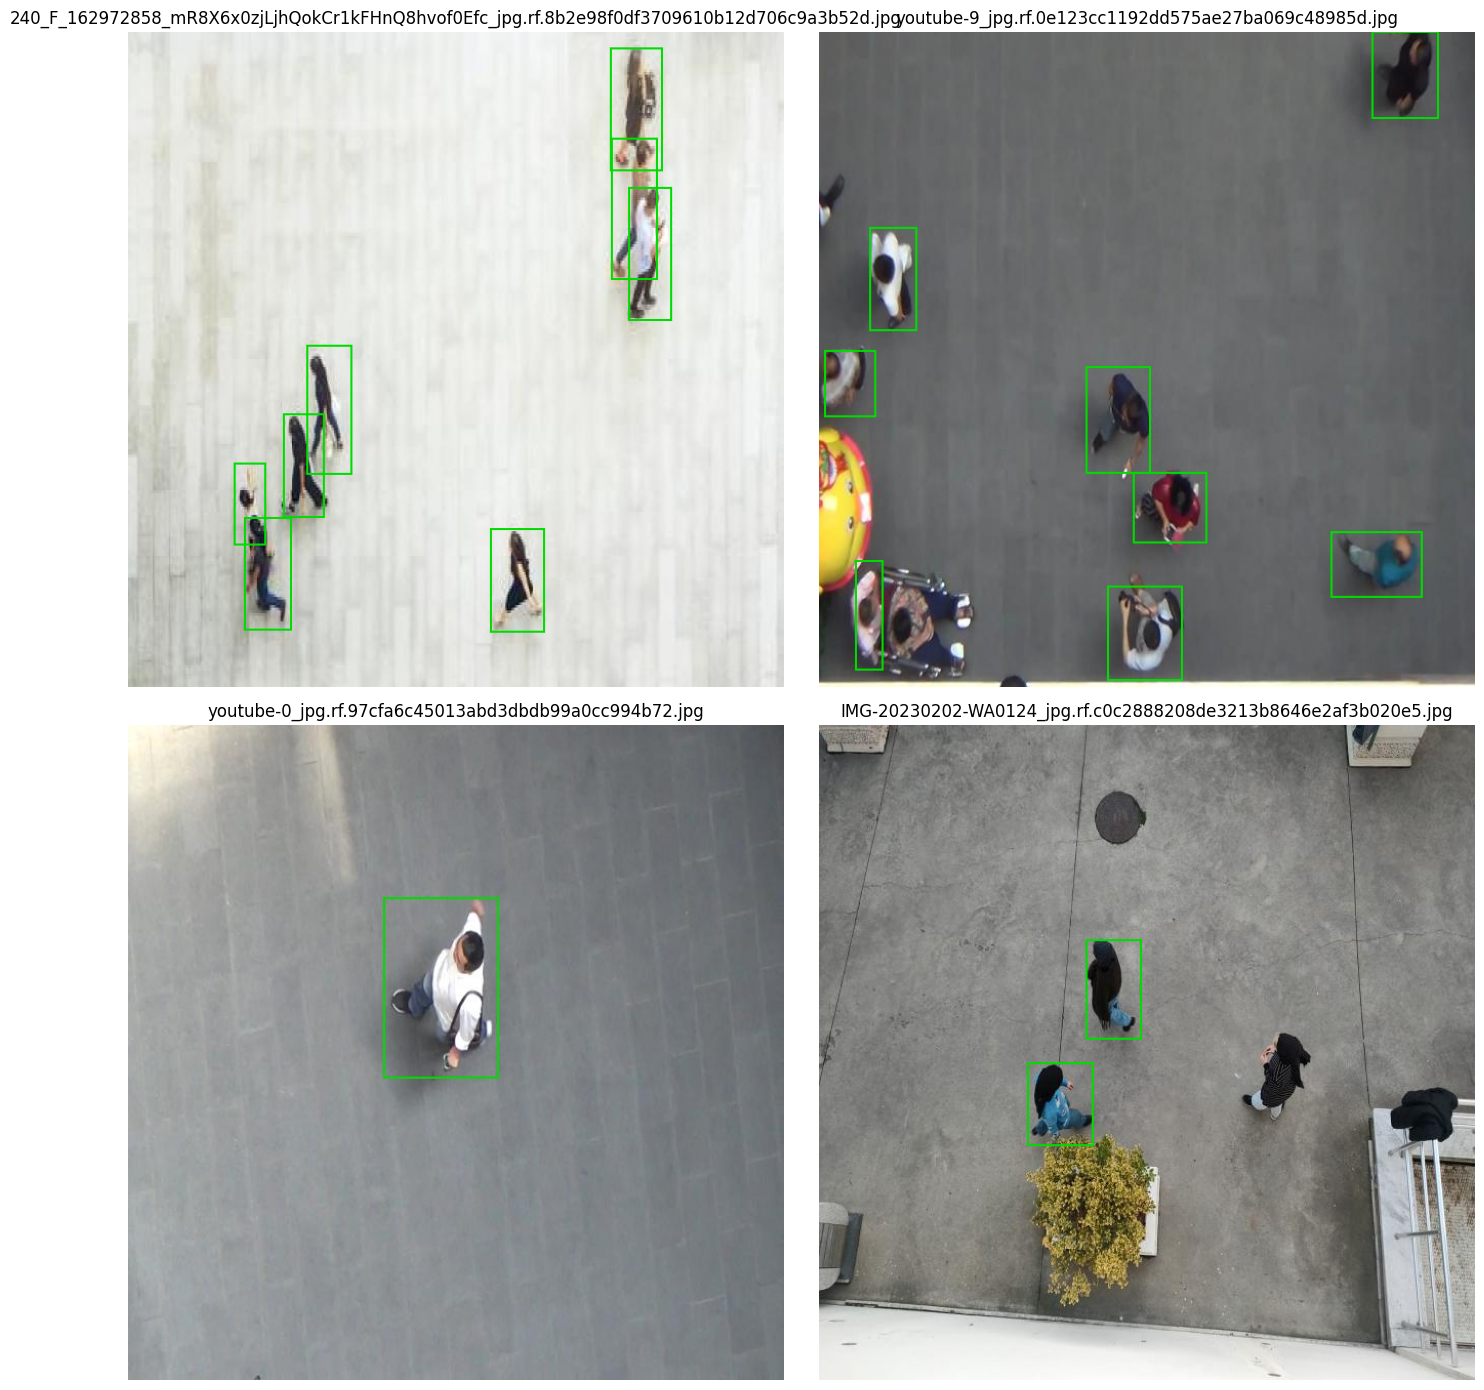

In [5]:
def read_boxes(label_path: Path, width: int, height: int):
    boxes = []
    for line in label_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        _, xc, yc, bw, bh = map(float, line.split())
        box_w = bw * width
        box_h = bh * height
        x1 = (xc * width) - (box_w / 2.0)
        y1 = (yc * height) - (box_h / 2.0)
        x2 = x1 + box_w
        y2 = y1 + box_h
        boxes.append((x1, y1, x2, y2))
    return boxes


sample_images = sorted((PROCESSED_ROOT / 'train' / 'images').glob('*.*'))
sample_images = random.sample(sample_images, k=min(4, len(sample_images)))

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()
for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    label_path = PROCESSED_ROOT / 'train' / 'labels' / f'{image_path.stem}.txt'
    for box in read_boxes(label_path, *image.size):
        draw.rectangle(box, outline=(0, 220, 0), width=2)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis('off')

for ax in axes[len(sample_images):]:
    ax.axis('off')
plt.tight_layout()


## Recommended warm-start recipe

These are the settings I recommend for the **first YOLO26n warm-start** on this dataset:

- `imgsz = 960` because the people are relatively small from overhead
- `epochs = 60` because the dataset is small and needs enough passes
- `batch = 8` as the starting point; if you hit GPU memory limits, drop to `4`
- `degrees = 180`, `fliplr = 0.5`, `flipud = 0.5` because top-down orientation is arbitrary
- `patience = 12` to stop early if it saturates
- `model = yolo26n.pt` because this is a warm-start experiment, not the final large-model run

In [6]:
TRAIN_CFG = {
    'model': MODEL_SOURCE,
    'data': str(PROCESSED_YAML),
    'imgsz': 960,
    'epochs': 60,
    'batch': 8,
    'device': '0',
    'workers': 4,
    'project': str(RUNS_DIR),
    'name': 'yolo26n_topdown_people_v1i_person',
    'patience': 12,
    'seed': 42,
    'degrees': 180,
    'fliplr': 0.5,
    'flipud': 0.5,
    'close_mosaic': 10,
    'exist_ok': True,
}

display(pd.DataFrame([TRAIN_CFG]).T.rename(columns={0: 'value'}))


,value
model,c:\Users\PC\Desktop\Term252\Senior Project II\...
data,c:\Users\PC\Desktop\Term252\Senior Project II\...
imgsz,960
epochs,60
batch,8
device,0
workers,4
project,c:\Users\PC\Desktop\Term252\Senior Project II\...
name,yolo26n_topdown_people_v1i_person
patience,12


In [7]:
# Run this cell to start training.
# If you get an out-of-memory error, change TRAIN_CFG['batch'] from 8 to 4 and rerun.

model = YOLO(TRAIN_CFG['model'])
train_results = model.train(
    data=TRAIN_CFG['data'],
    imgsz=TRAIN_CFG['imgsz'],
    epochs=TRAIN_CFG['epochs'],
    batch=TRAIN_CFG['batch'],
    device=TRAIN_CFG['device'],
    workers=TRAIN_CFG['workers'],
    project=TRAIN_CFG['project'],
    name=TRAIN_CFG['name'],
    patience=TRAIN_CFG['patience'],
    seed=TRAIN_CFG['seed'],
    degrees=TRAIN_CFG['degrees'],
    fliplr=TRAIN_CFG['fliplr'],
    flipud=TRAIN_CFG['flipud'],
    close_mosaic=TRAIN_CFG['close_mosaic'],
    exist_ok=TRAIN_CFG['exist_ok'],
)

train_results.save_dir


New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.9 torch-2.10.0.dev20251202+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\PC\Desktop\Term252\Senior Project II\datasets\processed\top_down_people_v1i_person_yolo26\data.yaml, degrees=180, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

WindowsPath('C:/Users/PC/Desktop/Term252/Senior Project II/train/runs/yolo26n_topdown_people_v1i_person')

In [8]:
RUN_DIR = RUNS_DIR / TRAIN_CFG['name']
BEST_MODEL_PATH = RUN_DIR / 'weights' / 'best.pt'
display(Markdown(f'**Run directory:** `{RUN_DIR}`'))
display(Markdown(f'**Best checkpoint:** `{BEST_MODEL_PATH}`'))

if BEST_MODEL_PATH.exists():
    best_model = YOLO(str(BEST_MODEL_PATH))
    val_results = best_model.val(data=str(PROCESSED_YAML), imgsz=TRAIN_CFG['imgsz'], device=TRAIN_CFG['device'])
    print(val_results)
else:
    print('Train first, then rerun this cell.')


**Run directory:** `c:\Users\PC\Desktop\Term252\Senior Project II\train\runs\yolo26n_topdown_people_v1i_person`

**Best checkpoint:** `c:\Users\PC\Desktop\Term252\Senior Project II\train\runs\yolo26n_topdown_people_v1i_person\weights\best.pt`

Ultralytics 8.4.14  Python-3.11.9 torch-2.10.0.dev20251202+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 555.290.8 MB/s, size: 66.2 KB)
val: Scanning C:\Users\PC\Desktop\Term252\Senior Project II\datasets\processed\top_down_people_v1i_person_yolo26\val\labels.cache... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63  0.0s
val: C:\Users\PC\Desktop\Term252\Senior Project II\datasets\processed\top_down_people_v1i_person_yolo26\val\images\cam_3_trimmed_00000096_jpg.rf.f9348332ec4e0133e1456244d68e69aa.jpg: 7 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.2s1.0ss
                   all         63        575      0.908      0.922      0.942      0.513
Speed: 6.5ms preprocess, 25.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved t

## Future fine-tune on your custom bottom-camera images

When your own bottom-camera images are ready, use the checkpoint from this warm-start and fine-tune it on the custom set.

Recommended fine-tune recipe:
- keep `imgsz = 960`
- fine-tune for `20–30` epochs
- lower the learning rate compared with the warm-start
- keep the label semantics the same: `person` boxes
- evaluate final performance on the custom set, not on this Roboflow set

If your custom bottom-camera dataset switches to **head labels**, do **not** fine-tune this checkpoint. Start from a head-labeled warm-start instead.

In [9]:
CUSTOM_DATA_YAML = ROOT / 'datasets' / 'processed' / 'project_bottom_v1_person' / 'data.yaml'

FINETUNE_CFG = {
    'base_checkpoint': str((RUNS_DIR / TRAIN_CFG['name'] / 'weights' / 'best.pt')),
    'data': str(CUSTOM_DATA_YAML),
    'imgsz': 960,
    'epochs': 25,
    'batch': 8,
    'device': '0',
    'workers': 4,
    'project': str(RUNS_DIR),
    'name': 'yolo26n_bottom_custom_finetune',
    'patience': 8,
    'seed': 42,
    'lr0': 0.002,
    'degrees': 180,
    'fliplr': 0.5,
    'flipud': 0.5,
    'close_mosaic': 15,
    'exist_ok': True,
}

display(pd.DataFrame([FINETUNE_CFG]).T.rename(columns={0: 'value'}))

# Uncomment and run when your custom bottom-camera dataset is ready.
# finetune_model = YOLO(FINETUNE_CFG['base_checkpoint'])
# finetune_model.train(
#     data=FINETUNE_CFG['data'],
#     imgsz=FINETUNE_CFG['imgsz'],
#     epochs=FINETUNE_CFG['epochs'],
#     batch=FINETUNE_CFG['batch'],
#     device=FINETUNE_CFG['device'],
#     workers=FINETUNE_CFG['workers'],
#     project=FINETUNE_CFG['project'],
#     name=FINETUNE_CFG['name'],
#     patience=FINETUNE_CFG['patience'],
#     seed=FINETUNE_CFG['seed'],
#     lr0=FINETUNE_CFG['lr0'],
#     degrees=FINETUNE_CFG['degrees'],
#     fliplr=FINETUNE_CFG['fliplr'],
#     flipud=FINETUNE_CFG['flipud'],
#     close_mosaic=FINETUNE_CFG['close_mosaic'],
#     exist_ok=FINETUNE_CFG['exist_ok'],
# )


,value
base_checkpoint,c:\Users\PC\Desktop\Term252\Senior Project II\...
data,c:\Users\PC\Desktop\Term252\Senior Project II\...
imgsz,960
epochs,25
batch,8
device,0
workers,4
project,c:\Users\PC\Desktop\Term252\Senior Project II\...
name,yolo26n_bottom_custom_finetune
patience,8
